In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image
import os

In [5]:
# Assume the input image is 'input_image.jpg' (you can change the name)
image_path = 'input_image.png'
img = Image.open(image_path).convert('RGB') # Convert image to RGB to ensure 3 channels
img_np = np.array(img)  # Convert to NumPy array

# Shape of the array: (height, width, channels) → reshape to 2D for K-means
height, width, channels = img_np.shape
img_2d = img_np.reshape(height * width, channels)  # (number of pixels, 3) for RGB

print(f"Image loaded: original size {height}x{width} with {channels} channels")
print(f"Original file size: {os.path.getsize(image_path) / 1024:.2f} KB")

Image loaded: original size 200x500 with 3 channels
Original file size: 56.23 KB


In [6]:
# Number of clusters (K) - you can change it, e.g., 16 for good compression
K = 16
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(img_2d)  # Clustering the colors

# Replace each pixel with the nearest centroid
labels = kmeans.predict(img_2d)
compressed_img_2d = kmeans.cluster_centers_[labels]  # New colors

# Reconstruct the 3D image
compressed_img_np = compressed_img_2d.reshape(height, width, channels).astype(np.uint8)
compressed_img = Image.fromarray(compressed_img_np)

# Save the compressed image
compressed_path = f'compressed_image_K{K}.jpg'
compressed_img.save(compressed_path)
print(f"Compressed image saved: {compressed_path}")
print(f"Compressed file size: {os.path.getsize(compressed_path) / 1024:.2f} KB")

Compressed image saved: compressed_image_K16.jpg
Compressed file size: 24.28 KB


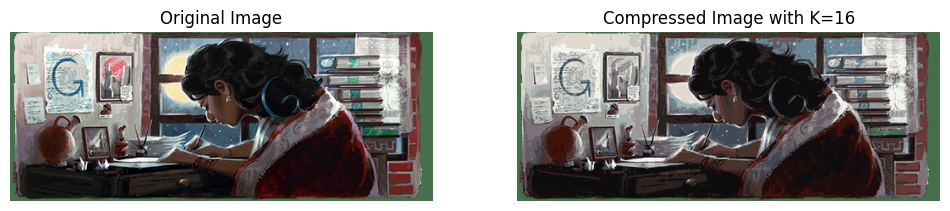

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_np)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(compressed_img_np)
axes[1].set_title(f'Compressed Image with K={K}')
axes[1].axis('off')

plt.show()

In [8]:
# Test multiple K values and compare size/quality
for k in [2, 4, 8, 32]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(img_2d)
    labels = kmeans.predict(img_2d)
    compressed_2d = kmeans.cluster_centers_[labels]
    compressed_np = compressed_2d.reshape(height, width, channels).astype(np.uint8)
    compressed = Image.fromarray(compressed_np)
    path = f'compressed_K{k}.jpg'
    compressed.save(path)
    print(f"K={k}: Size = {os.path.getsize(path) / 1024:.2f} KB")

K=2: Size = 19.15 KB
K=4: Size = 23.68 KB
K=8: Size = 23.82 KB
K=32: Size = 24.03 KB


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [12]:
# CSV file link from GitHub
url = 'https://reneshbedre.github.io/assets/posts/tsne/tsne_scores.csv'

# Load the data using pandas
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

X = df[['t-SNE-1', 't-SNE-2']].values

# Standardize the data to improve DBSCAN performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (4406, 2)

First 5 rows of the dataset:
     t-SNE-1    t-SNE-2
0  10.846841 -16.712580
1  24.794334 -16.775398
2   2.953309  13.379048
3  27.262146 -31.886690
4 -23.015728  64.468376


In [13]:
# DBSCAN parameters - you can tune eps and min_samples
eps = 0.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# Add labels to the dataframe for visualization
df['cluster'] = labels

print(f"Number of clusters: {len(np.unique(labels)) - (1 if -1 in labels else 0)} (excluding noise)")
print(f"Cluster distribution:\n{df['cluster'].value_counts()}")

Number of clusters: 2 (excluding noise)
Cluster distribution:
cluster
0    4174
1     232
Name: count, dtype: int64


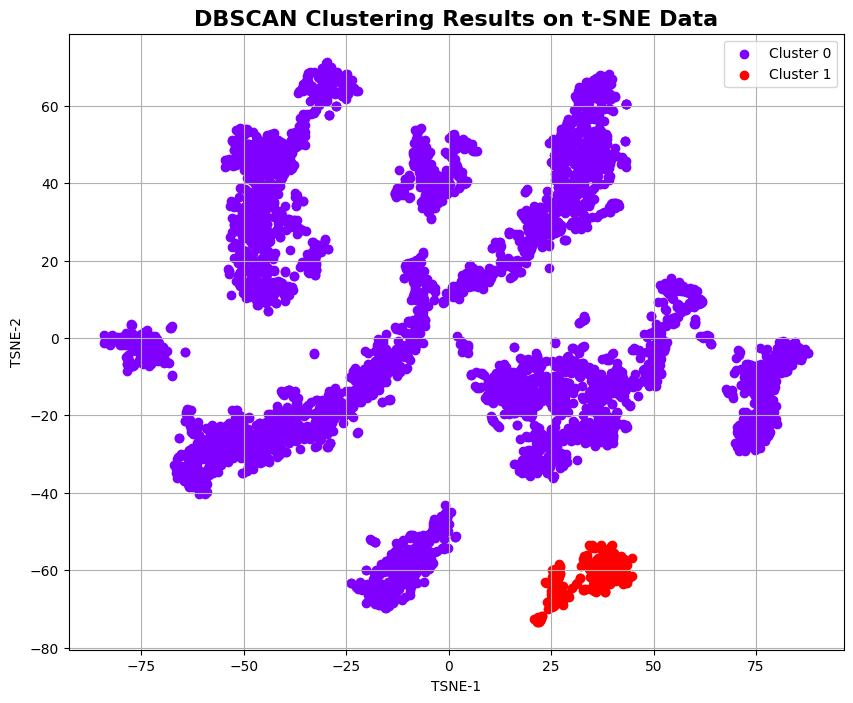

In [14]:
# Cluster coloring
unique_labels = np.unique(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 8))
for i, label in enumerate(unique_labels):
    if label == -1:
        # Color noise black
        color = 'black'
    else:
        color = colors[i]

    plt.scatter(X[labels == label, 0], X[labels == label, 1],
                color=color, label=f'Cluster {label}' if label != -1 else 'Noise')

plt.title('DBSCAN Clustering Results on t-SNE Data', fontsize=16, fontweight='bold')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import seaborn as sns

In [16]:
# Load IRIS dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Optional for comparison, but not used for clustering

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Standardize features (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('target', axis=1))  # Without target

Dataset shape: (150, 5)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


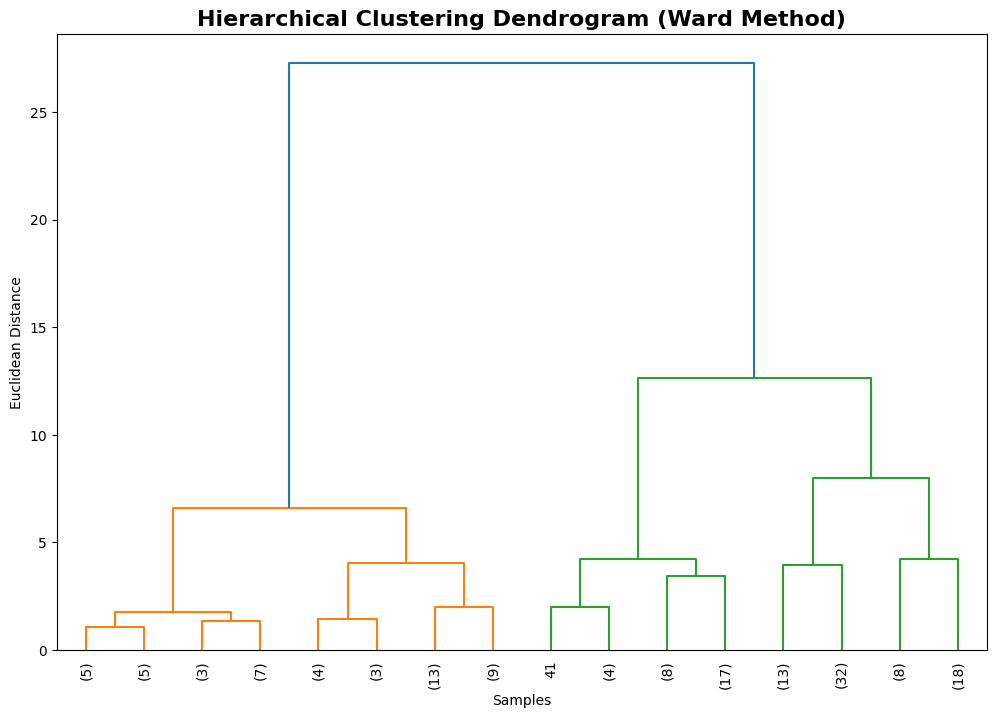

In [17]:
# Calculate linkage for dendrogram (ward method for linkage)
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(Z, truncate_mode='level', p=3, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Method)', fontsize=16, fontweight='bold')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()

For 2 clusters: Silhouette Score = 0.5770
For 3 clusters: Silhouette Score = 0.4467
For 4 clusters: Silhouette Score = 0.4006
For 5 clusters: Silhouette Score = 0.3306
For 6 clusters: Silhouette Score = 0.3149
For 7 clusters: Silhouette Score = 0.3170
For 8 clusters: Silhouette Score = 0.3109
For 9 clusters: Silhouette Score = 0.3114
For 10 clusters: Silhouette Score = 0.3161


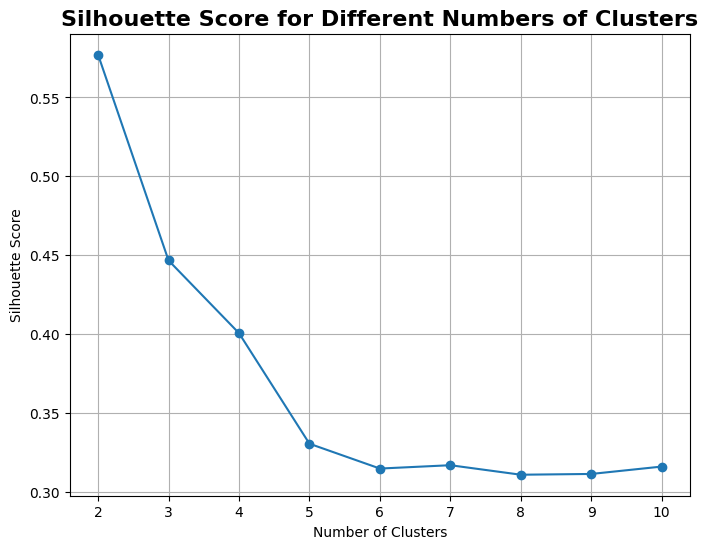


Best number of clusters: 2 (with Score 0.5770)


In [18]:
# Test number of clusters from 2 to 10
silhouette_scores = []
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = clusterer.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"For {n_clusters} clusters: Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Numbers of Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('silhouette_scores.png', dpi=300)
plt.show()

# Select the best number of clusters (max score)
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters: {best_n_clusters} (with Score {max(silhouette_scores):.4f})")

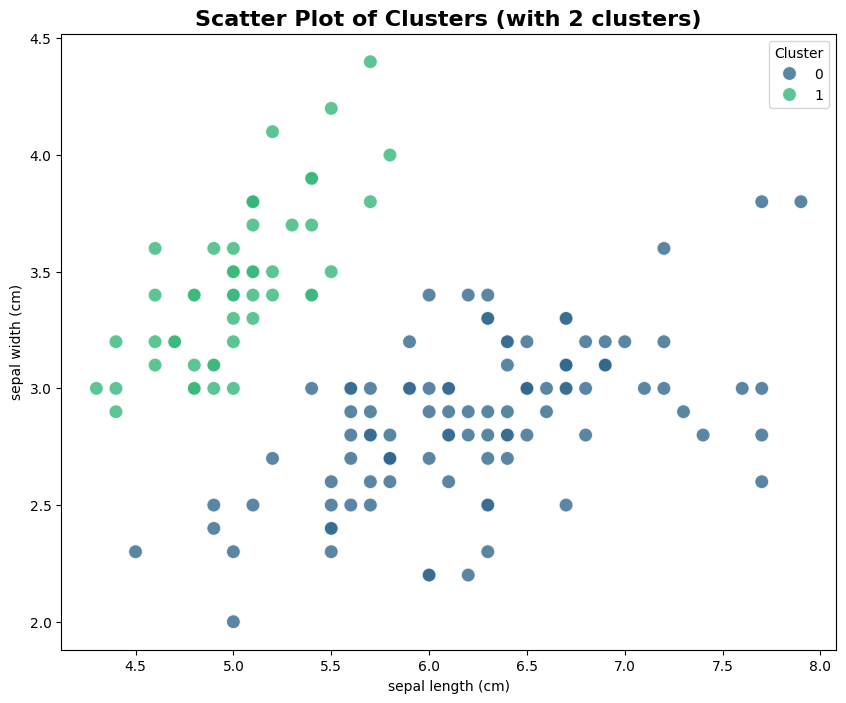

In [19]:
# Apply clustering with the best number of clusters
clusterer = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
df['cluster'] = clusterer.fit_predict(X_scaled)

# Plot Scatter Plot (using the first two features for simplicity)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df[iris.feature_names[0]], y=df[iris.feature_names[1]],
                hue=df['cluster'], palette='viridis', s=100, alpha=0.8)
plt.title(f'Scatter Plot of Clusters (with {best_n_clusters} clusters)', fontsize=16, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(title='Cluster')
plt.savefig('scatter_plot.png', dpi=300)
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [21]:
# Load Iris dataset
iris = load_iris()
X = iris.data  # features only (no labels for unsupervised clustering)

# Standardize the data (important for GMM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape: {X_scaled.shape}")
print("First 5 rows:\n", X_scaled[:5])

Dataset shape: (150, 4)
First 5 rows:
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


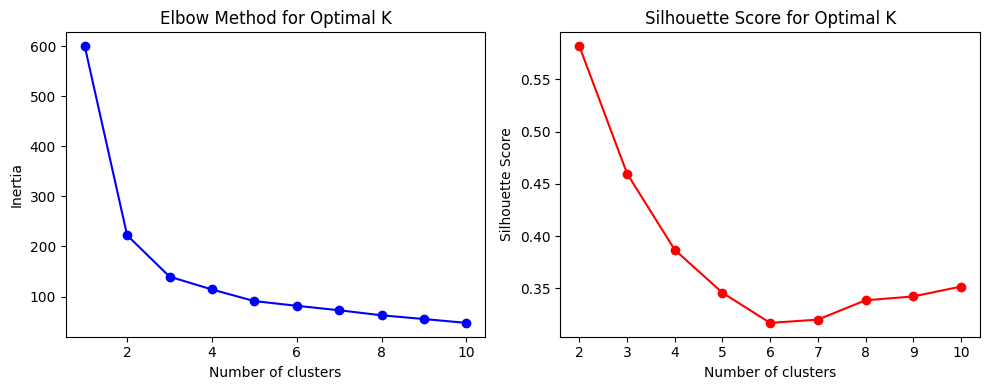

Suggested number of clusters: 3


In [22]:
# Use KMeans to estimate optimal K (elbow method + silhouette)
inertias = []
sil_scores = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    if k > 1:
        sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range[1:], sil_scores, 'ro-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Choose best K (e.g., where elbow bends or max silhouette)
best_k = 3  # Iris typically has 3 clusters
print(f"Suggested number of clusters: {best_k}")

In [23]:
# Fit GMM with the chosen number of components
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# Predict cluster labels
labels = gmm.predict(X_scaled)

# Predict probabilities for each point
probs = gmm.predict_proba(X_scaled)

print(f"GMM fitted with {best_k} components")
print("Sample probabilities (first 5):\n", probs[:5])

GMM fitted with 3 components
Sample probabilities (first 5):
 [[2.74503381e-011 1.00000000e+000 0.00000000e+000]
 [1.16033052e-007 9.99999884e-001 0.00000000e+000]
 [9.72921434e-009 9.99999990e-001 5.88168010e-278]
 [2.02193473e-007 9.99999798e-001 3.33173699e-141]
 [9.67775891e-012 1.00000000e+000 0.00000000e+000]]


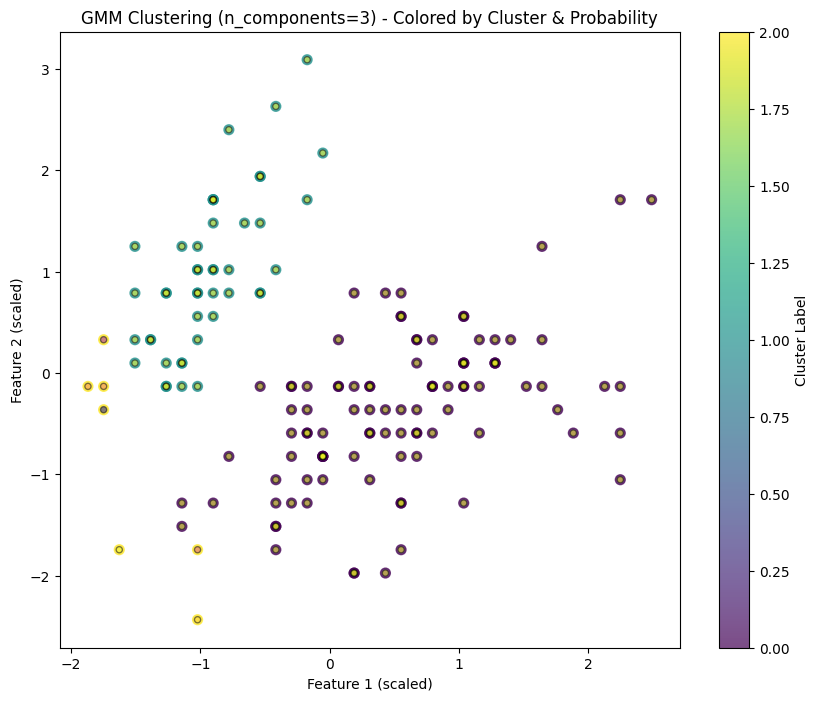

In [24]:
# Use first two features for visualization (PCA-like projection)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Color by probability (optional: size or alpha based on max prob)
max_prob = np.max(probs, axis=1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=max_prob, cmap='plasma', s=20, alpha=0.5, edgecolor='k')

plt.title(f'GMM Clustering (n_components={best_k}) - Colored by Cluster & Probability')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

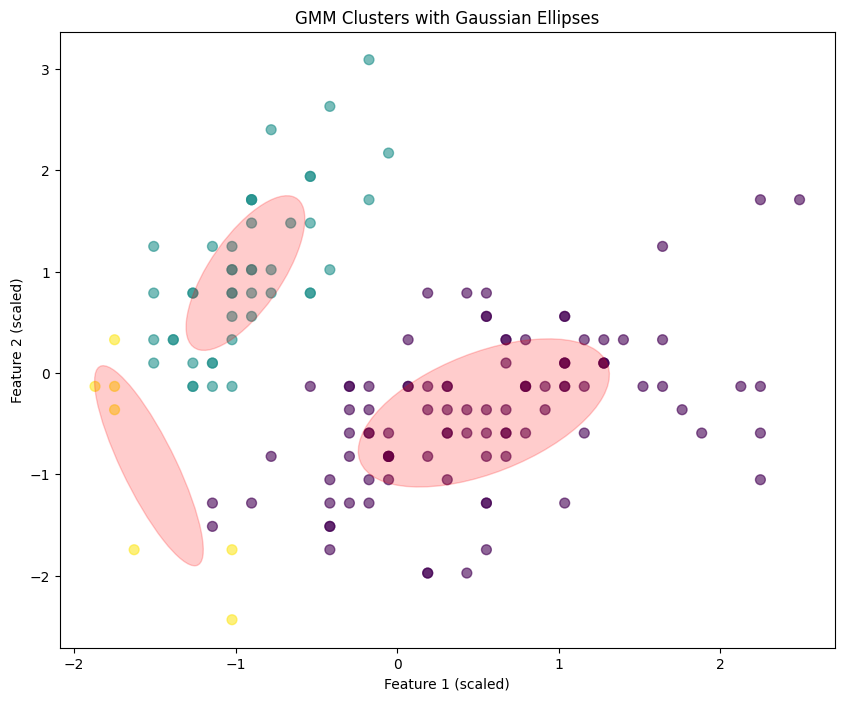

In [25]:
def draw_ellipse(position, covariance, ax, **kwargs):
    """Draw the ellipse representing a Gaussian component"""
    U, s, Vt = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(s)
    ellipse = Ellipse(position, width, height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Plot clusters with ellipses
plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6)

# Draw ellipses for each component
for pos, covar in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(pos[:2], covar[:2, :2], plt.gca(), alpha=0.2, color='red')  # only 2D projection

plt.title('GMM Clusters with Gaussian Ellipses')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.savefig('gmm_ellipses.png', dpi=300)
plt.show()

In [26]:
# Summary
print("Cluster distribution:\n", np.bincount(labels))
print("Mean of each component:\n", gmm.means_)
print("Covariances shape:", gmm.covariances_.shape)

# Optional: Compare with true labels (for validation, though unsupervised)
true_labels = iris.target
print("Silhouette Score (GMM):", silhouette_score(X_scaled, labels))

Cluster distribution:
 [98 45  7]
Mean of each component:
 [[ 0.53745909 -0.39369142  0.6693573   0.64500292]
 [-0.93852253  0.98617415 -1.29410958 -1.24871335]
 [-1.53616188 -0.9148767  -1.05760659 -1.00758605]]
Covariances shape: (3, 4, 4)
Silhouette Score (GMM): 0.4751434694267145
